## A notebook to analyze groups of trackarrays  

### Reading in, combining, and making measurements

In [1]:
import croparray as ca
from pathlib import Path

In [2]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Files & Directories
DATA_DIR_1 = Path("/mnt/c/Users/tstasevi/Documents/Tim-Marianas/20260203/12xSunTAg-KDM5B-XBP1SA-MS2/CombinedStacks/CropArrays")
DATA_DIR_2 = Path("/mnt/c/Users/tstasevi/Documents/Tim-Marianas/20260203/12xSunTAg-KDM5B-XBP1SA-MS2_w_3xFLAG-ZNF598/CombinedStacks/CropArrays")
LABELS = ['-ZNF598','+ZNF598']
OUTPUT = Path("/mnt/c/Users/tstasevi/Documents/Tim-Marianas/20260203/analyzed.nc") 

nc_files_1 = sorted(DATA_DIR_1.glob("*.nc"))
nc_files_2 = sorted(DATA_DIR_2.glob("*.nc"))

# Measurement parameters
REF_CH = 0  # Optional reference channel for best_z_proj (if use_zc=False, i.e. when Z not tracked)
DISK_R = 5  # Radius of disk in pixels to measure signal
DISK_BG = 7 # Radius of single pixel ring around disk to measure background 
ROLL_N = 3  # Rolling z-average for signal measurement.

In [3]:
my_ta = ca.build.open_measure_concat(
    groups=[nc_files_1, nc_files_2],
    dims=["exp", "fov"],
    labels=[["-ZNF598", "+ZNF598"], None],
    measure_kwargs=dict(ref_ch=REF_CH, disk_r=DISK_R, disk_bg=DISK_BG, roll_n=ROLL_N, drop_int=True),
    join="outer",
)

In [ ]:
my_ta.build.me

In [5]:
my_ta

TrackArray(tracks=665, t=10)

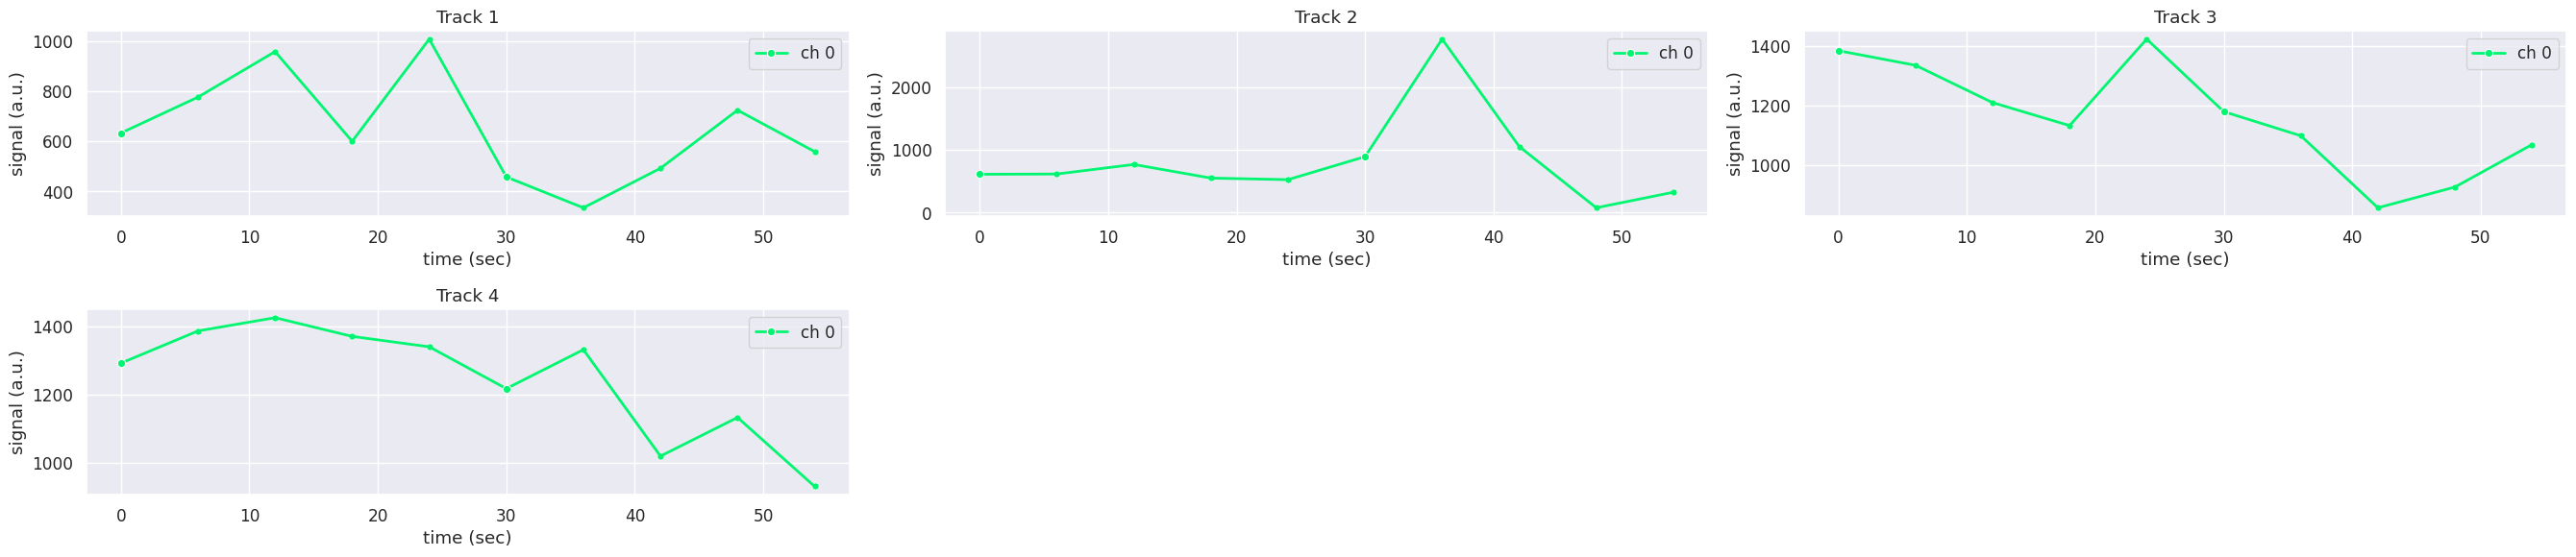

In [27]:
# Plot signals
my_ta.sel(exp='-ZNF598',fov='fov1').tplot.plot_track_signal_traces(track_ids=[1,2,3,4],figsize=(9,3))

In [ ]:
# Create binary masks from "best_z" so morphological properties
my_ta.ops.apply(
    ca.tools.binarize_crop_manual,
    channels=[0],               # Channel used to generate mask
    source="best_z",            # Image layer to threshold (typically z-projected signal)
    out_name="ch{ch}_mask",     # Output mask variable name (→ "ch0_mask")
    #group_exclude_dims = ("track_id", "t", "ch", "x", "y", "z"),

    # Recommended parameters forwarded directly to binarize_crop_manual(...)
    func_kwargs=dict(
        q=0.45,                 # Threshold at 45% after intensity normalization
        q_range=(0.02, 0.999),  # Normalize intensities using 2%–99.9% quantile range
        q_positive_only=True,   # Ignore negative pixels (important for best_z)
        close_px=1,             # Morphological closing (bridge small gaps)
        smooth_px=0,            # Light smoothing of mask edges
        fill_holes=False,       # Do not fill internal holes
        return_uint8=True,      # Store mask as uint8 (0/1)
        morph_px=0,             # Apply a dilation of final mask (morph_pix > 0; <0 for erosion)
    ),
);

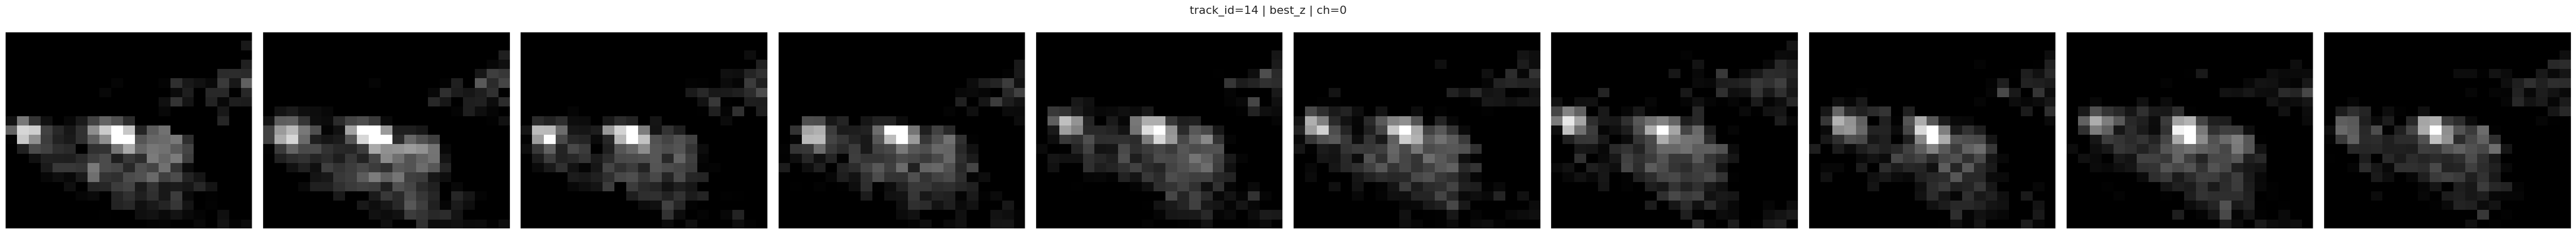

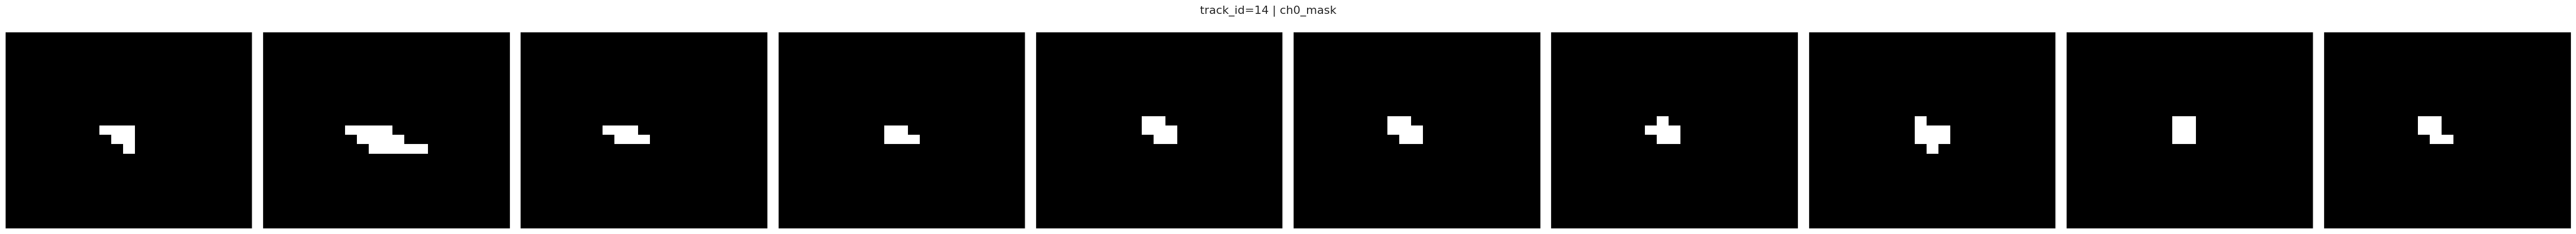

In [26]:
# Check masks, if desired (without napari)
my_ta.sel(exp='+ZNF598', fov='fov2').tplot.plot_trackarray_crops(track_ids=[14],t=(0,10,1),suppress_labels=True);
my_ta.sel(exp='+ZNF598', fov='fov2').tplot.plot_trackarray_crops(track_ids=[14],t=(0,10,1),suppress_labels=True,layer="ch0_mask");

In [28]:
# Make measurements of desired properties 
# See https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops
my_ta.measure.mask_props(source ="ch0_mask", props=['eccentricity','major_axis_length_px','minor_axis_length_px']);

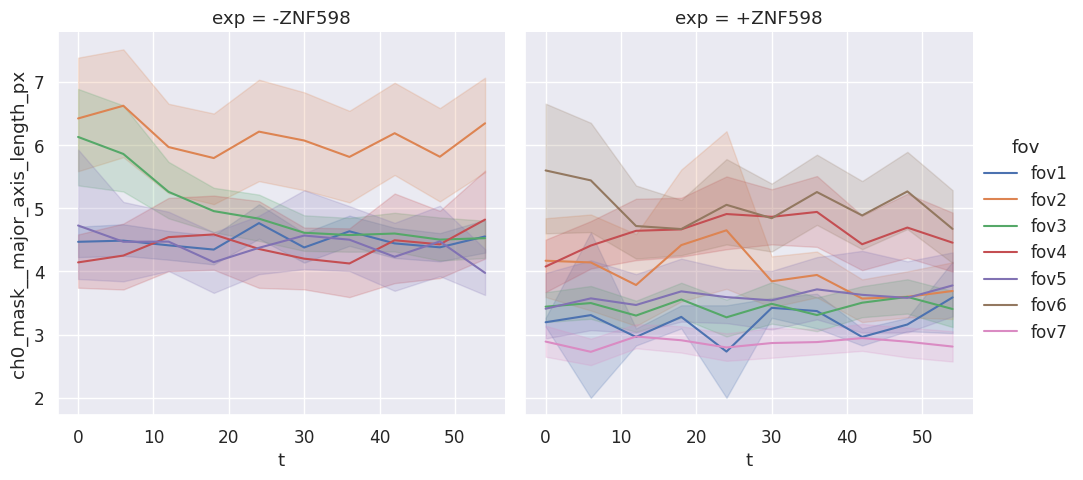

In [33]:
# Make plots using seaborn (relplot, distplot, and catplot supported)
my_ta.plot.relplot(
    x="t", y="ch0_mask__major_axis_length_px",
    kind="line",
    hue="fov",
    col='exp',
    # col_wrap=4,
    #hue="ch",
    # estimator=None,          # prevents seaborn from averaging
    facet_kws={"sharey": True},
)


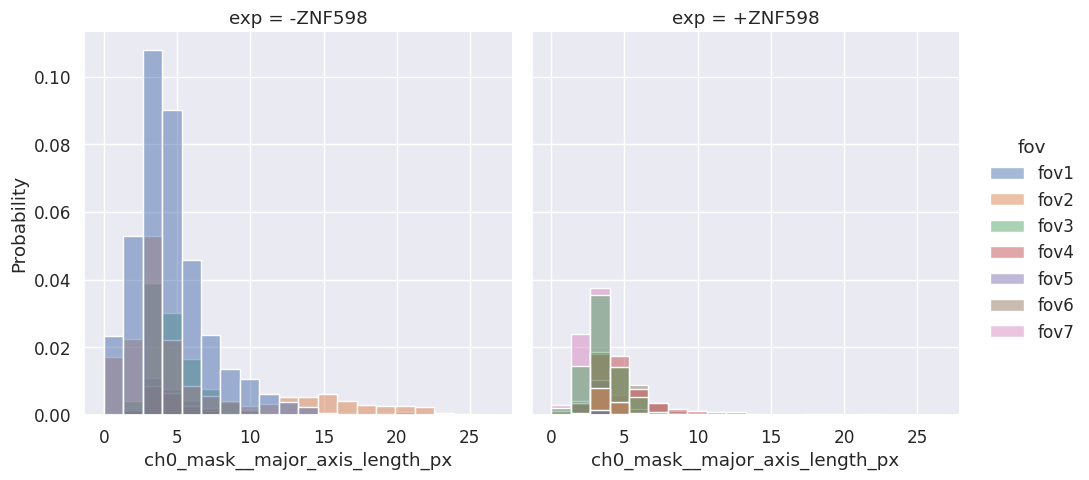

In [42]:
# Make plots using seaborn (relplot, distplot, and catplot supported)
my_ta.plot.displot(
    x="ch0_mask__major_axis_length_px",
    hue="fov",
    col='exp',
    bins=20,
    facet_kws={"sharey": True},
    stat="probability", 
)

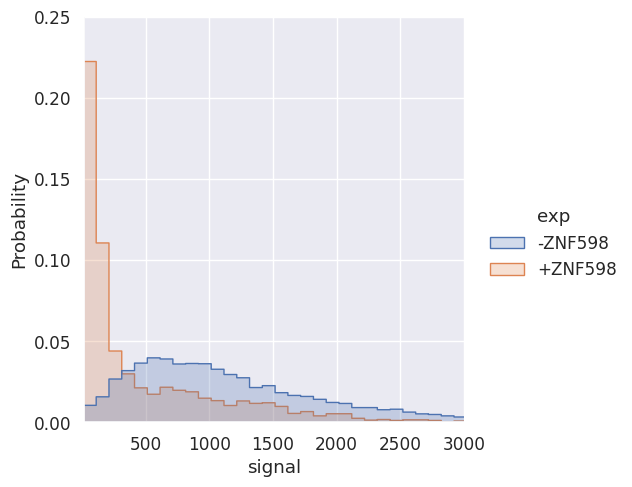

In [49]:
g=my_ta.plot.displot( x="signal", hue="exp", bins=300, element="step", common_norm=False, stat="probability", aspect=1)
g.set(xlim=(20,3000))
g.set(ylim=(0,0.25))

In [ ]:
new_path = OUTPUT_DIR + nc_files_1 .with_name(p.stem + "_measured.nc")

In [ ]:
# Save combined and analyzed crop/trackarray
# from pathlib import Path

if out_file is not None:
    out_path = Path(out_file)
    if out_path.exists():
        raise FileExistsError(f"{out_file} already exists. Refusing to overwrite.")
    ds.to_netcdf(out_file, mode="w")
 

### Manual Fitering of saved crop/trackarrays

In [ ]:
# Quick and user-friendly manual filtering of tracks with napari 
# Create and save filter names (e.g. a 'bad' filter to remove noisy crops/tracks)
# Can also create filters like 'toi' to highlight tracks of interest  
viewer, layers, ft = my_ta.napari.manual_filter_montage(
    row="track_id",                 
    col="t",
    filter_name="bad",
    show=("best_z", "ch0_mask"),
    ch=0,
    colormaps={"ch0_mask":"magenta", "best_z":"green", "stretchy":"yellow"},
    output_dir=DATA_DIR_1.parent,
    show_tile_text=True, # adds layer showin crop coords
)

NameError: name 'DATA_DIR' is not defined

In [ ]:
# Just viewing layers for comparison 
viewer, layers = test.napari.montage_viewer(
    row="track_id",
    col="t",
    show=("best_z", "ch0_mask"),
    #ch=[0, 1, 2],  # RGB
    colormaps={"ch0_mask": "magenta","best_z": "green"},
    image_contrast=(0,100),
    show_tile_text=True,
)


/home/tstasevi/miniconda3/envs/croparray_env/lib/python3.10/site-packages/napari/layers/utils/style_encoding.py:257: RuntimeWarning: Applying the encoding failed. Using the safe fallback value instead.
  warnings.warn(
/home/tstasevi/miniconda3/envs/croparray_env/lib/python3.10/site-packages/napari/layers/utils/style_encoding.py:257: RuntimeWarning: Applying the encoding failed. Using the safe fallback value instead.
  warnings.warn(


DEBUG image_contrast: <class 'tuple'> (0, 100)


/home/tstasevi/miniconda3/envs/croparray_env/lib/python3.10/site-packages/napari/utils/colormaps/colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
